In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

In [3]:
print("Available Seaborn Datasets:")
print(sns.get_dataset_names())

Available Seaborn Datasets:
['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [4]:
diamonds = sns.load_dataset('diamonds')

print("Shape:", diamonds.shape)
print("\nFirst 5 rows:")
diamonds.head()

Shape: (53940, 10)

First 5 rows:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
print("Summary Statistics:")
diamonds.describe()

Summary Statistics:


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [6]:
print("Data Types:")
print(diamonds.dtypes)
print("\nMissing Values:")
print(diamonds.isnull().sum())

Data Types:
carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

Missing Values:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


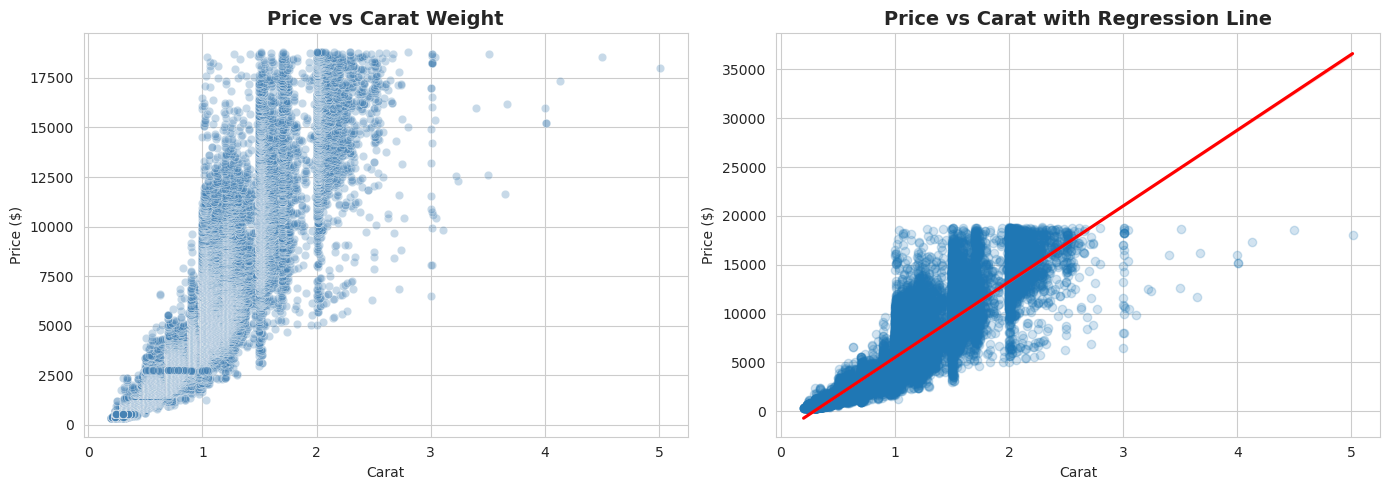

Correlation between Carat and Price: 0.922


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=diamonds, x='carat', y='price', alpha=0.3,
                color='steelblue', ax=axes[0])
axes[0].set_title('Price vs Carat Weight', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Carat')
axes[0].set_ylabel('Price ($)')

sns.regplot(data=diamonds, x='carat', y='price', scatter_kws={'alpha': 0.2},
            line_kws={'color': 'red'}, ax=axes[1])
axes[1].set_title('Price vs Carat with Regression Line', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Carat')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

print(f"Correlation between Carat and Price: {diamonds['carat'].corr(diamonds['price']):.3f}")

/tmp/ipykernel_490/906303403.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diamonds, x='cut', y='price', palette='Set2',
/tmp/ipykernel_490/906303403.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_price_cut = diamonds.groupby('cut')['price'].mean().reindex(
/tmp/ipykernel_490/906303403.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_cut.index, y=avg_price_cut.values,


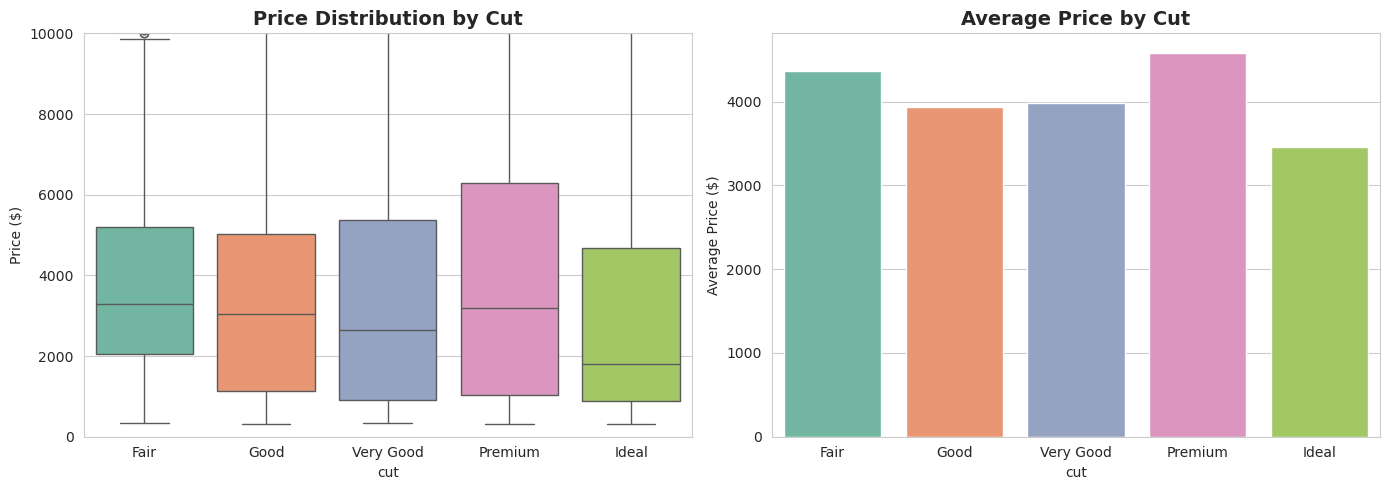

Average Price by Cut:
cut
Premium      4584.26
Fair         4358.76
Very Good    3981.76
Good         3928.86
Ideal        3457.54
Name: price, dtype: float64


/tmp/ipykernel_490/906303403.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(diamonds.groupby('cut')['price'].mean().round(2).sort_values(ascending=False))


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=diamonds, x='cut', y='price', palette='Set2',
            order=['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], ax=axes[0])
axes[0].set_title('Price Distribution by Cut', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].set_ylim(0, 10000)

avg_price_cut = diamonds.groupby('cut')['price'].mean().reindex(
    ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'])
sns.barplot(x=avg_price_cut.index, y=avg_price_cut.values,
            palette='Set2', ax=axes[1])
axes[1].set_title('Average Price by Cut', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Price ($)')

plt.tight_layout()
plt.show()

print("Average Price by Cut:")
print(diamonds.groupby('cut')['price'].mean().round(2).sort_values(ascending=False))

/tmp/ipykernel_490/3340885017.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diamonds, x='clarity', y='price', palette='viridis',
/tmp/ipykernel_490/3340885017.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diamonds, x='color', y='price', palette='coolwarm',


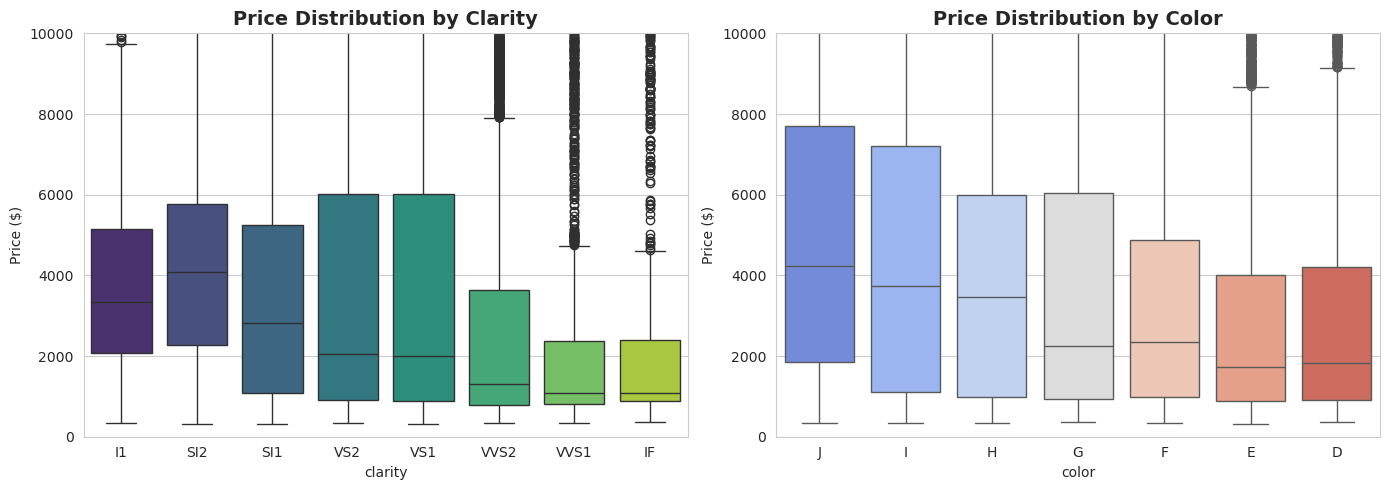

Average Price by Clarity:
clarity
SI2     5063.03
SI1     3996.00
VS2     3924.99
I1      3924.17
VS1     3839.46
VVS2    3283.74
IF      2864.84
VVS1    2523.11
Name: price, dtype: float64

Average Price by Color:
color
J    5323.82
I    5091.87
H    4486.67
G    3999.14
F    3724.89
D    3169.95
E    3076.75
Name: price, dtype: float64


/tmp/ipykernel_490/3340885017.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(diamonds.groupby('clarity')['price'].mean().round(2).sort_values(ascending=False))
/tmp/ipykernel_490/3340885017.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(diamonds.groupby('color')['price'].mean().round(2).sort_values(ascending=False))


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
sns.boxplot(data=diamonds, x='clarity', y='price', palette='viridis',
            order=clarity_order, ax=axes[0])
axes[0].set_title('Price Distribution by Clarity', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].set_ylim(0, 10000)

color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
sns.boxplot(data=diamonds, x='color', y='price', palette='coolwarm',
            order=color_order, ax=axes[1])
axes[1].set_title('Price Distribution by Color', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price ($)')
axes[1].set_ylim(0, 10000)

plt.tight_layout()
plt.show()

print("Average Price by Clarity:")
print(diamonds.groupby('clarity')['price'].mean().round(2).sort_values(ascending=False))

print("\nAverage Price by Color:")
print(diamonds.groupby('color')['price'].mean().round(2).sort_values(ascending=False))

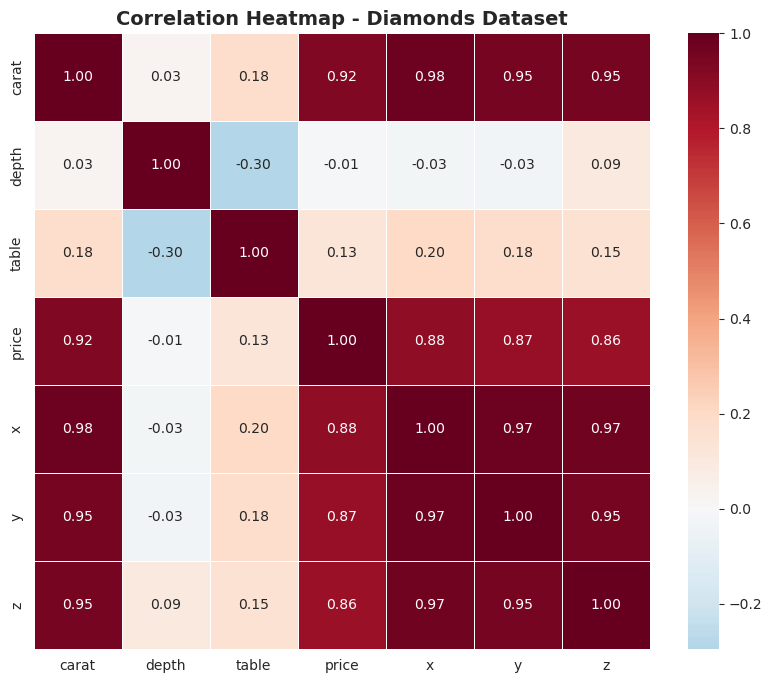

Correlation with Price:
price    1.000
carat    0.922
x        0.884
y        0.865
z        0.861
table    0.127
depth   -0.011
Name: price, dtype: float64


In [10]:
numeric_diamonds = diamonds.select_dtypes(include=[np.number])
corr_matrix = numeric_diamonds.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Heatmap - Diamonds Dataset', fontsize=14, fontweight='bold')
plt.show()

print("Correlation with Price:")
print(corr_matrix['price'].sort_values(ascending=False).round(3))

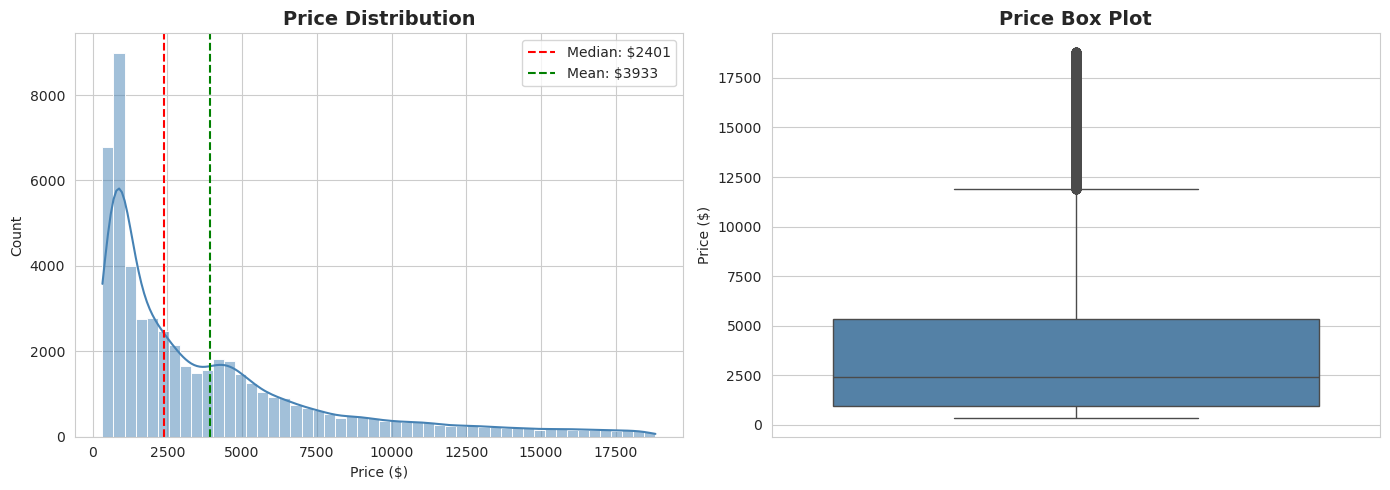

Price Statistics:
Mean: $3932.80
Median: $2401.00
Std Dev: $3989.44
Q1: $950.00
Q3: $5324.25
IQR: $4374.25


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=diamonds, x='price', bins=50, kde=True,
             color='steelblue', ax=axes[0])
axes[0].set_title('Price Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].axvline(diamonds['price'].median(), color='red', linestyle='--',
                label=f'Median: ${diamonds["price"].median():.0f}')
axes[0].axvline(diamonds['price'].mean(), color='green', linestyle='--',
                label=f'Mean: ${diamonds["price"].mean():.0f}')
axes[0].legend()

sns.boxplot(data=diamonds, y='price', color='steelblue', ax=axes[1])
axes[1].set_title('Price Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

print("Price Statistics:")
print(f"Mean: ${diamonds['price'].mean():.2f}")
print(f"Median: ${diamonds['price'].median():.2f}")
print(f"Std Dev: ${diamonds['price'].std():.2f}")
print(f"Q1: ${diamonds['price'].quantile(0.25):.2f}")
print(f"Q3: ${diamonds['price'].quantile(0.75):.2f}")
print(f"IQR: ${diamonds['price'].quantile(0.75) - diamonds['price'].quantile(0.25):.2f}")

/tmp/ipykernel_490/274933002.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_clarity = diamonds.groupby('clarity')['price'].mean().reindex(clarity_order)
/tmp/ipykernel_490/274933002.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_by_color = diamonds.groupby('color')['price'].mean().reindex(color_order)


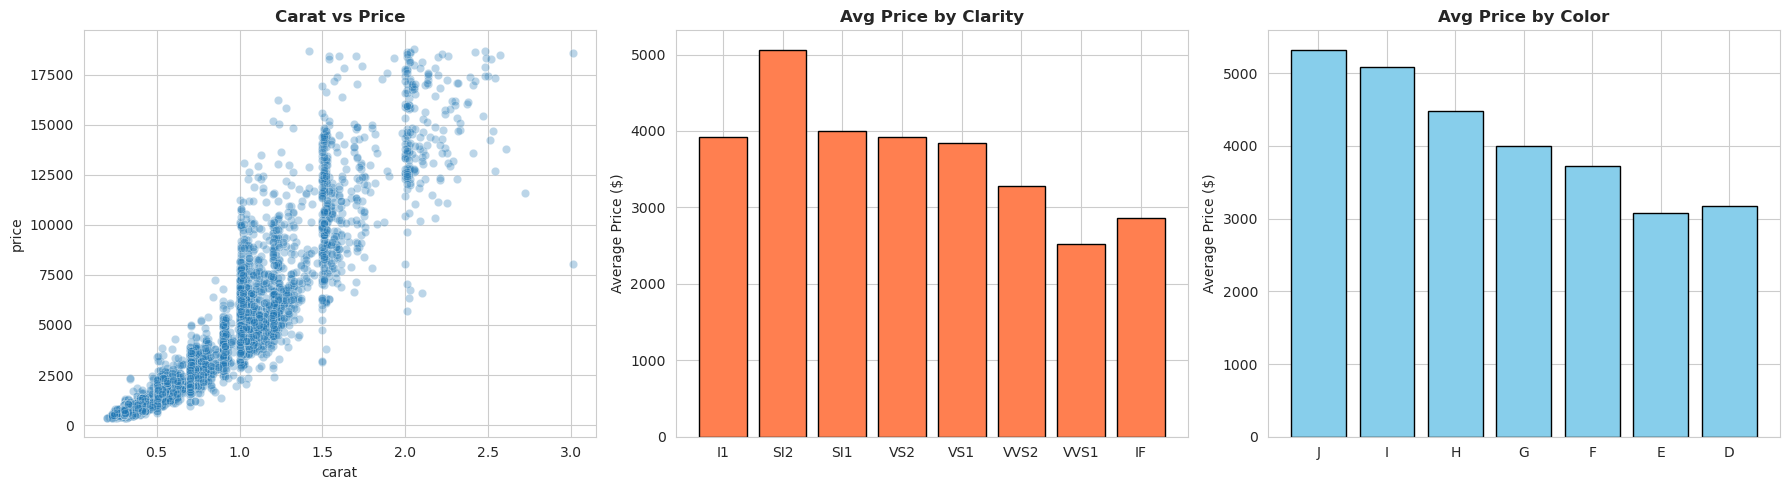

Impact on Price (Eta-squared):
Carat (as numeric): r² = 0.849
Cut: η² = 0.013
Color: η² = 0.031
Clarity: η² = 0.027


/tmp/ipykernel_490/274933002.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = diamonds.groupby(group_col)[target_col]


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=diamonds.sample(5000), x='carat', y='price',
                alpha=0.3, ax=axes[0])
axes[0].set_title('Carat vs Price', fontsize=12, fontweight='bold')

avg_by_clarity = diamonds.groupby('clarity')['price'].mean().reindex(clarity_order)
axes[1].bar(avg_by_clarity.index, avg_by_clarity.values, color='coral', edgecolor='black')
axes[1].set_title('Avg Price by Clarity', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Average Price ($)')

avg_by_color = diamonds.groupby('color')['price'].mean().reindex(color_order)
axes[2].bar(avg_by_color.index, avg_by_color.values, color='skyblue', edgecolor='black')
axes[2].set_title('Avg Price by Color', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Average Price ($)')

plt.tight_layout()
plt.show()

from scipy import stats

def eta_squared(group_col, target_col):
    groups = diamonds.groupby(group_col)[target_col]
    grand_mean = diamonds[target_col].mean()
    ss_between = sum(len(group) * (group.mean() - grand_mean)**2 for name, group in groups)
    ss_total = sum((diamonds[target_col] - grand_mean)**2)
    return ss_between / ss_total

print("Impact on Price (Eta-squared):")
print(f"Carat (as numeric): r² = {diamonds['carat'].corr(diamonds['price'])**2:.3f}")
print(f"Cut: η² = {eta_squared('cut', 'price'):.3f}")
print(f"Color: η² = {eta_squared('color', 'price'):.3f}")
print(f"Clarity: η² = {eta_squared('clarity', 'price'):.3f}")

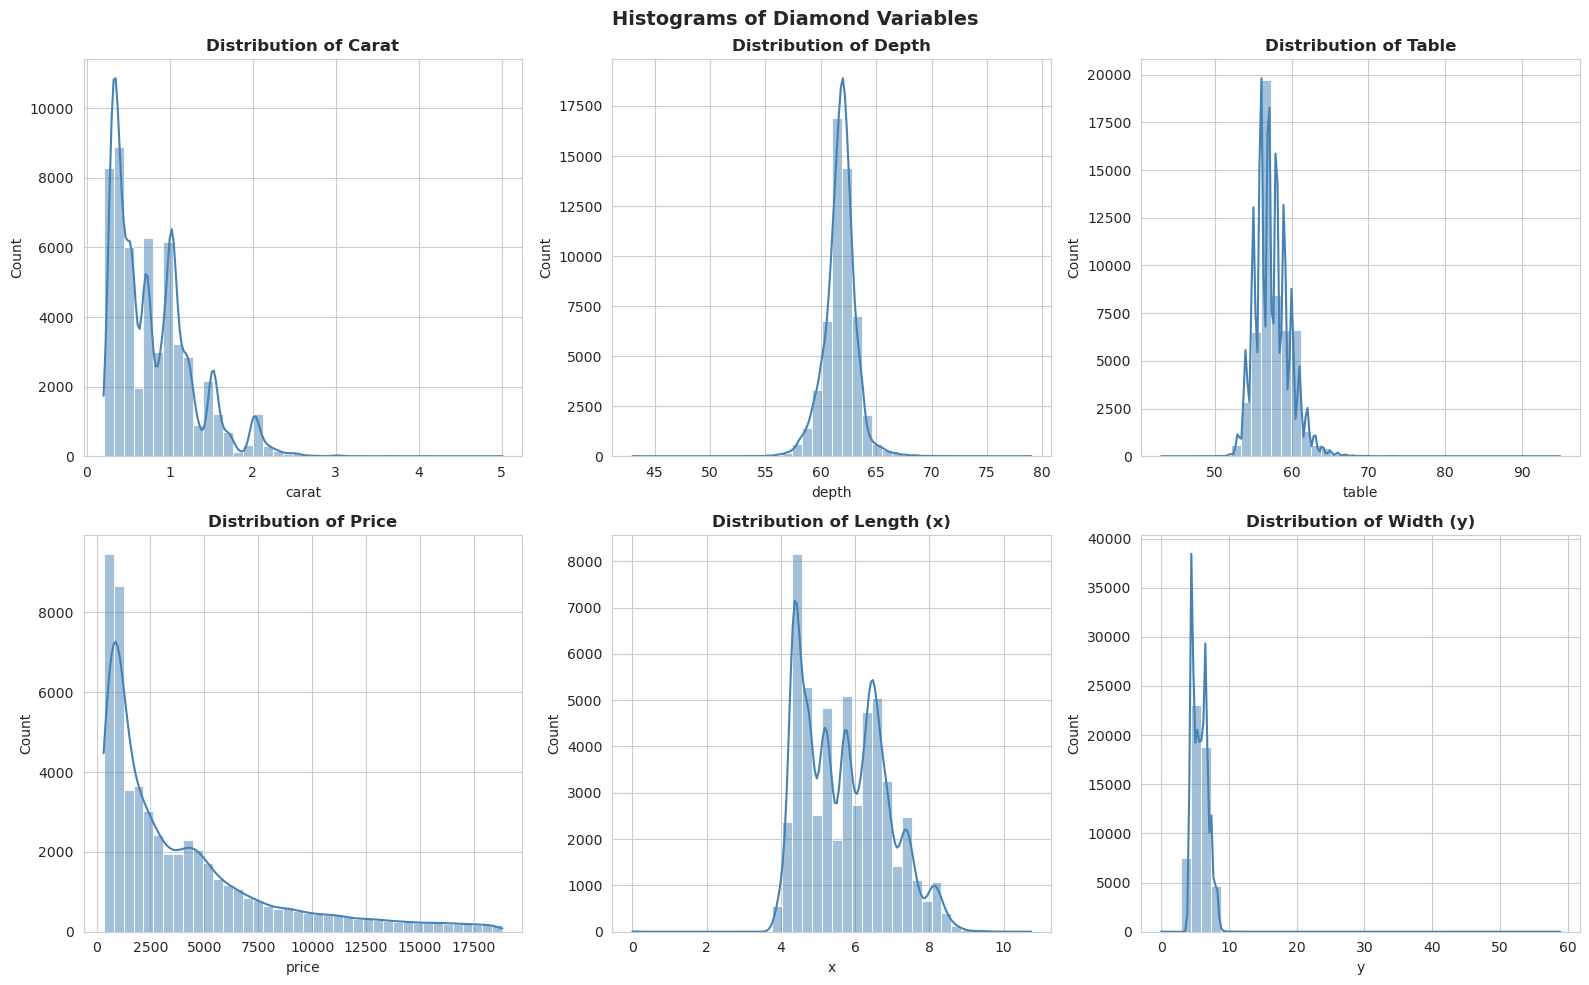

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y']
titles = ['Carat', 'Depth', 'Table', 'Price', 'Length (x)', 'Width (y)']

for ax, col, title in zip(axes.flatten(), numeric_cols, titles):
    sns.histplot(data=diamonds, x=col, bins=40, kde=True,
                 color='steelblue', ax=ax)
    ax.set_title(f'Distribution of {title}', fontsize=12, fontweight='bold')

plt.suptitle('Histograms of Diamond Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()